# Importing from a segmentation mask

In modern image analysis, a wide range of powerful segmentation methods are available, many of which come from advances in computer vision and machine learning. In biological imaging, for example, tools such as Cellpose, StarDist and DeepCell are commonly used to identify and segment individual cells from microscopy images.

These segmentation algorithms typically produce an output image where each pixel is assigned an integer label corresponding to a specific object (e.g. a cell). This is often stored as a TIFF file or similar, where pixels with the same value belong to the same segmented region.

In this tutorial, we’ll walk through how to take one of these segmentation masks images (here it'll be a .tif but this could be any image file type) and convert it into a MuSpAn domain, where each labelled mask becomes an object that can be analysed further.

For demonstration purposes, we’ll use an example segmentation generated with Cellpose, available here:
https://huggingface.co/spaces/mouseland/cellpose

Although MuSpAn provides utilities to load this data directly, we’ll first take a look at the image itself to better understand its structure before importing it.

### Basic import from a segmentation mask image

Text(0.5, 1.0, 'Conic 1564 masks (TIFF)')

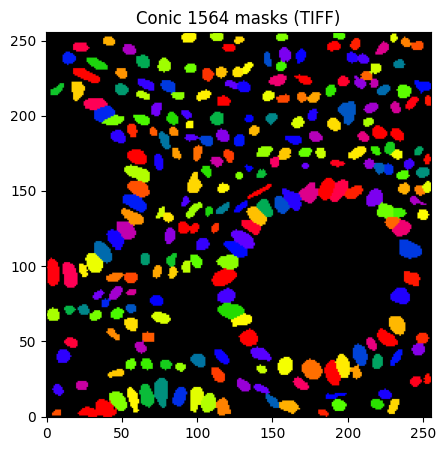

In [1]:
import muspan as ms
import skimage as sk
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import os

# load the TIFF file
path_to_tiff_file = os.path.dirname(ms.datasets.__file__) + '/data/conic_1564_masks.tif' 
label_image = sk.io.imread(path_to_tiff_file)


# setting the color
cmap = plt.get_cmap('prism')
cmap.set_under('black') 

# plot the image
fig,ax = plt.subplots(figsize=(5,5))
ax.imshow(label_image, cmap=cmap, vmin=1,origin='lower')
ax.set_title('Conic 1564 masks (TIFF)')

The example we’ll use comes from the CoNIC challenge (Colon Nuclei Identification and Counting) and shows a region of colon histopathology tissue. What you’re looking at here is not the original microscopy image, but its corresponding segmentation mask.

In this mask, each object (for example, an individual nucleus) is represented by a unique integer value, meaning that all pixels with the same value belong to the same segmented region. To make this easier to interpret visually, we’ve applied a colour map so that different objects appear in different colours.

MuSpAn provides a convenient importer for this type of data. Using the `segmentation_mask_to_domain` function from the io submodule, we can convert each labelled pixel region into a MuSpAn shape, allowing us to work with these objects directly within a domain.

In [2]:
# convert the TIFF file to a domain
domain_from_tiff = ms.io.segmentation_mask_to_domain(path_to_tiff_file,mask_label_name='Cellpose IDs',collection_name='mask_objects')

# print the domain
print(domain_from_tiff)

Domain name: conic_1564_masks
Number of objects: 254
Collections: ['mask_objects']
Labels: ['Cellpose IDs'] 
Networks: [] 
Distance matrices: []


The generated domain contains a collection called 'mask_objects', which holds the 254 segmented objects extracted from the mask. Each object is also assigned a label (here we call this Cellpose IDs as the segmentation was performed by Cellpose), allowing us to retain a link back to the original pixel values in the segmentation mask.

Let’s now explore this domain and compare it with the original segmentation mask to see how the regions have been translated into MuSpAn objects.

Text(0.5, 1.0, 'MuSpAn Domain')

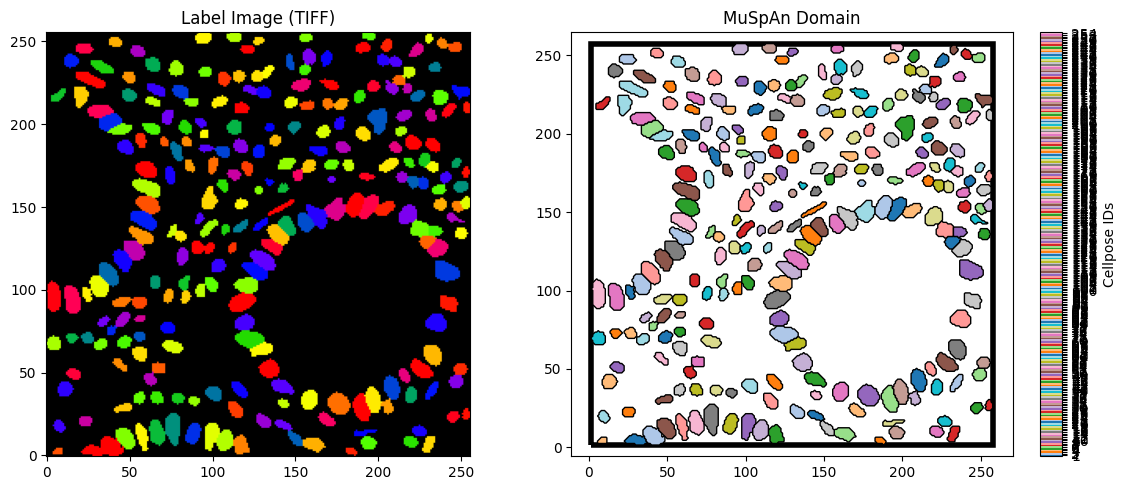

In [3]:
fig,ax=plt.subplots(1,2,figsize=(12,5))

# plot the TIFF file
ax[0].imshow(label_image, origin='lower',cmap=cmap, vmin=1) 
ax[0].set_title('Label Image (TIFF)')

# plot the domain
ms.visualise.visualise(domain_from_tiff, 'Cellpose IDs', ax=ax[1], shape_kwargs=dict(alpha=1),show_boundary=True)
ax[1].set_title('MuSpAn Domain')

We can see that each segmented region has been converted into a shape within the domain, and the corresponding mask ID has been preserved as a label (Cellpose IDs), as described earlier. This makes it straightforward to link any additional information about the segmented regions back to the corresponding MuSpAn objects.

### Import objects as points


In some cases, you may prefer a simpler representation and import these objects as points rather than full shapes. This can be done by enabling the as_points parameter in the importer.

Text(0.5, 1.0, 'MuSpAn Domain')

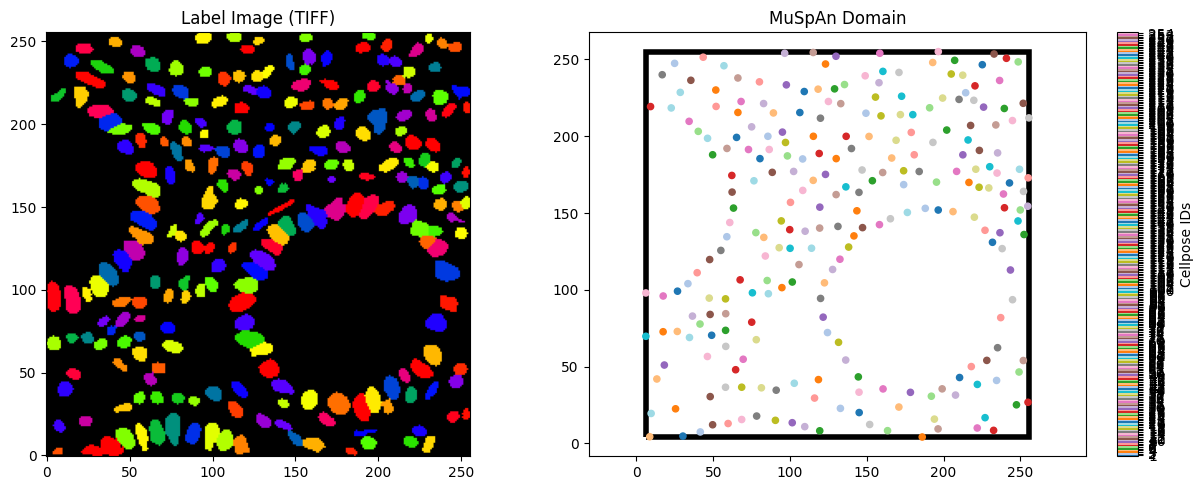

In [5]:
# convert the TIFF file to a domain as points
domain_from_tiff_as_points = ms.io.segmentation_mask_to_domain(path_to_tiff_file,mask_label_name='Cellpose IDs',as_points=True)

fig,ax=plt.subplots(1,2,figsize=(13,5))
# plot the TIFF file
ax[0].imshow(label_image, origin='lower',cmap=cmap, vmin=1) 
ax[0].set_title('Label Image (TIFF)')
# plot the domain as points
ms.visualise.visualise(domain_from_tiff_as_points, 'Cellpose IDs', ax=ax[1], marker_size=20,show_boundary=True)
ax[1].set_title('MuSpAn Domain')

### Simplify imported shapes

In some cases, you may want to retain objects as shapes, but find that the pixel-level boundaries are overly detailed or noisy. To address this, MuSpAn provides options to simplify the geometry of each shape.

By using the `simplify_shapes` parameter, along with `simplify_tolerance`, you can reduce the complexity of the polygons. This process uses the Ramer–Douglas–Peucker algorithm, where the tolerance controls the degree of simplification, higher values result in simpler, less detailed shapes. In practice, this removes small jagged edges and pixelation artefacts while preserving the overall structure of each object.

Text(0.5, 1.0, 'MuSpAn Domain')

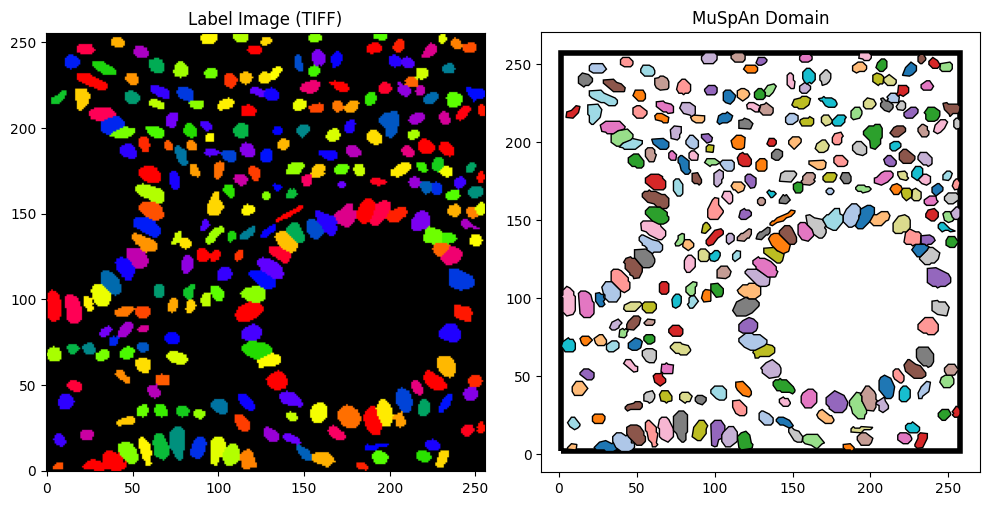

In [6]:
# convert the TIFF file to a domain as simplified shapes
domain_from_tiff_simp_shapes = ms.io.segmentation_mask_to_domain(path_to_tiff_file,mask_label_name='Cellpose IDs',simplify_shapes=True,simplify_tolerance=0.5)

# plot the TIFF file and the domain as simplified shapes
fig,ax=plt.subplots(1,2,figsize=(10,5))

ax[0].imshow(label_image, origin='lower',cmap=cmap, vmin=1) 
ax[0].set_title('Label Image (TIFF)')

ms.visualise.visualise(domain_from_tiff_simp_shapes, 'Cellpose IDs', ax=ax[1],shape_kwargs=dict(alpha=1),show_boundary=True,add_cbar=False)
ax[1].set_title('MuSpAn Domain')

### Aligning external data to objects

There will be instances where external analysis has been conducted on the labelled image and information corresponding to these labelled objects should be added as labels. For this situation, we also return the ordered arrays of muspan object IDs and the provided mask IDs from the segmentation image directly. We can return these additional outputs using the `return_muspan_and_annotation_ids` parameter in `segmentation_mask_to_domain()`.



In [12]:
# convert the TIFF file to a domain and return the muspan_ids and mask_ids
domain_from_tiff,muspan_ids,mask_ids = ms.io.segmentation_mask_to_domain(path_to_tiff_file,mask_label_name='Cellpose IDs',collection_name='annotated_objects',return_muspan_and_mask_ids=True)

# Create a DataFrame to display muspan_ids and tiff_ids (use to visualising the table)
ids_table = pd.DataFrame({'MuSpAn IDs': muspan_ids, 'Mask IDs': mask_ids})

# Print the table
ids_table

,MuSpAn IDs,Mask IDs
0,0,1
1,1,2
2,2,3
3,3,4
4,4,5
...,...,...
249,249,250
250,250,251
251,251,252
252,252,253


This can be useful for aligning external data to the objects using the mask IDs. For example, if cell phenotyping has been performed in using another platform, then we would like to add cell types to each of the objects that define cells. Let's make a set random of labels to add objects in our domain.

In [ ]:
# make a set of random labels
random_labels = np.random.choice(['A', 'B', 'C'], size=len(mask_ids))    

# Create a DataFrame to mimic typical label table with the random labels
example_cell_type_table = pd.DataFrame({'Mask IDs': mask_ids,'Random label':random_labels})

# Print the example label table
example_cell_type_table

,Mask IDs,Random label
0,1,B
1,2,C
2,3,B
3,4,C
4,5,B
...,...,...
249,250,A
250,251,B
251,252,C
252,253,A


Let's add these labels to the corresponding MuSpAn objects and visualise

(<Figure size 1000x800 with 2 Axes>, <Axes: >)

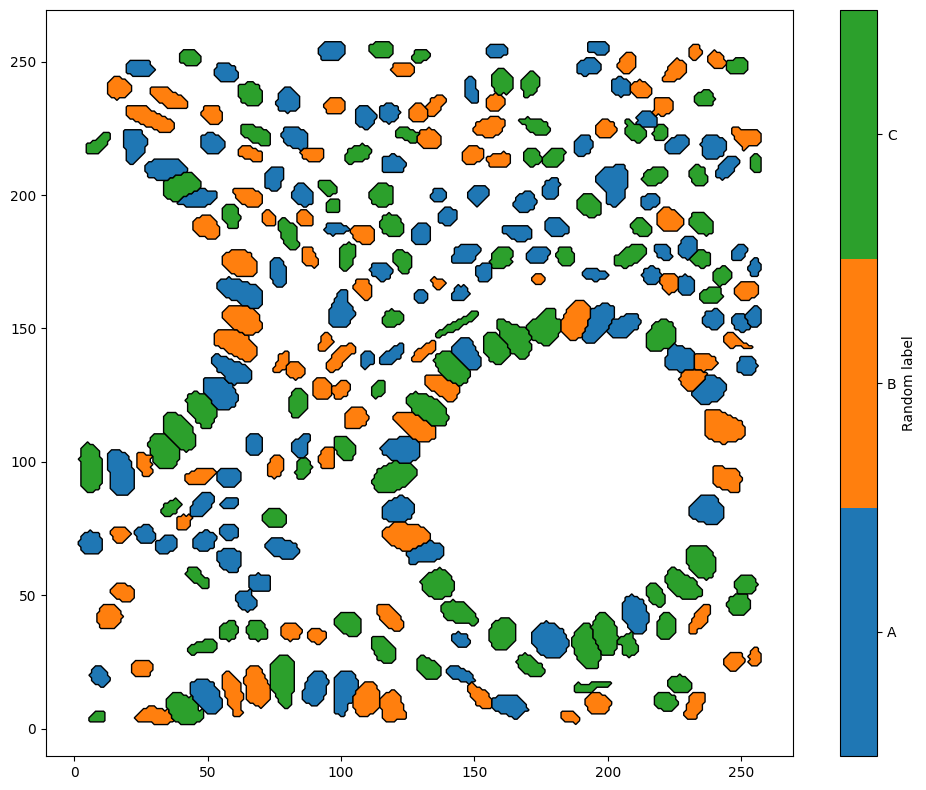

In [16]:
# align the labels to the MuSpAn IDs using the mask IDs as a reference
labels_aligned_to_muspan_ids = [example_cell_type_table.loc[example_cell_type_table['Mask IDs'] == mask_id, 'Random label'].values[0] for mask_id in mask_ids]

# add the labels to the domain using the aligned labels and the corresponding MuSpAn IDs
domain_from_tiff.add_labels('Random label', labels_aligned_to_muspan_ids,add_labels_to=muspan_ids)

# plot the domain with the cell type labels
ms.visualise.visualise(domain_from_tiff, 'Random label', shape_kwargs=dict(alpha=1))

For more advanced usage, we recommend exploring the full MuSpAn documentation on importing domains from segmentation masks. In particular, you can align and attach additional metadata to each object during import using parameters such as annotated_label_name, making it easier to incorporate external annotations or measurements into your analysis.